# Q2 + Q8 — Global SHAP Feature Importance & Data Quality Audit
Validates `src/xai/global_shap.py`. Answers:
- **Q2**: What features drive demand across all SKUs?
- **Q8**: Are there data quality issues affecting model reliability?

## 1) Imports and Paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

import sys
sys.path.insert(0, str(Path('..').resolve() / 'src'))

from xai.global_shap import (
    compute_global_shap,
    rank_feature_importance,
    feature_quality_audit,
    generate_global_explanation_text,
)

ROOT        = Path('..').resolve()
DATA_DIR    = ROOT / 'data' / 'processed' / 'LGBM_XGB_7_V3'
MODEL_PATH  = ROOT / 'artifacts' / 'models' / 'tuned_lgbm_7_v3.joblib'
REPORTS_DIR = ROOT / 'artifacts' / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_DIR:  ', DATA_DIR)
print('MODEL_PATH:', MODEL_PATH)

DATA_DIR:   C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\data\processed\LGBM_XGB_7_V3
MODEL_PATH: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\tuned_lgbm_7_v3.joblib


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Load Model and Test Data

In [2]:
model = joblib.load(MODEL_PATH)
print('Model loaded:', type(model))

test_df = pd.read_csv(DATA_DIR / 'test.csv')
test_df['date'] = pd.to_datetime(test_df['date'], errors='coerce')

TARGET     = 'aggregated_sales_7'
DROP_COLS  = [TARGET, 'date', 'item_id']
feature_cols = [c for c in test_df.columns if c not in DROP_COLS]

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET].copy()

print(f'X_test shape: {X_test.shape}')
print(f'Features ({len(feature_cols)}):', feature_cols)

Model loaded: <class 'sklearn.pipeline.Pipeline'>
X_test shape: (15807, 31)
Features (31): ['is_month_end', 'sales_lag_7', 'sales_roll_mean_7', 'aggregated_sell_price', 'discount_depth', 'event_christmas_7', 'event_easter_7', 'event_eid_al_fitr_7', 'event_eid_al_adha_7', 'event_fathers_day_7', 'event_halloween_7', 'event_mothers_day_7', 'event_newyear_7', 'event_orthodox_christmas_7', 'event_orthodox_easter_7', 'event_ramadan_starts_7', 'event_thanksgiving_7', 'event_valentines_day_7', 'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_roll_mean_2', 'sales_roll_mean_4', 'sales_roll_std_4', 'price_lag_1', 'price_change_bucket', 'item_mean_train', 'item_std_train', 'item_cv_train', 'weeks_since_first_seen', 'snap_relevant']


## 3) Compute Global SHAP (Q2)

In [3]:
shap_values = compute_global_shap(model, X_test, max_samples=1000)

print('SHAP explanation type:', type(shap_values))
print('SHAP values shape:    ', np.asarray(shap_values.values).shape)
print('Feature names (first 5):', shap_values.feature_names[:5])

SHAP explanation type: <class 'shap._explanation.Explanation'>
SHAP values shape:     (1000, 31)
Feature names (first 5): ['num__is_month_end', 'num__sales_lag_7', 'num__sales_roll_mean_7', 'num__aggregated_sell_price', 'num__discount_depth']


## 4) Rank Feature Importance

In [4]:
importance_df = rank_feature_importance(shap_values)
print(importance_df.to_string(index=False))

                        feature  mean_abs_shap
               num__sales_lag_7       6.433485
           num__item_mean_train       4.115556
         num__sales_roll_mean_7       2.268573
            num__item_std_train       0.996534
    num__weeks_since_first_seen       0.741051
             num__item_cv_train       0.403613
               num__sales_lag_1       0.327433
             num__snap_relevant       0.205924
     num__aggregated_sell_price       0.096068
           num__event_newyear_7       0.094445
               num__price_lag_1       0.090210
               num__sales_lag_2       0.079885
    num__event_valentines_day_7       0.055902
              num__is_month_end       0.048889
            num__event_easter_7       0.045164
      num__event_thanksgiving_7       0.038402
       num__price_change_bucket       0.032569
            num__discount_depth       0.032295
               num__sales_lag_4       0.023745
num__event_orthodox_christmas_7       0.018434
       num__e

## 5) SHAP Summary Bar Plot

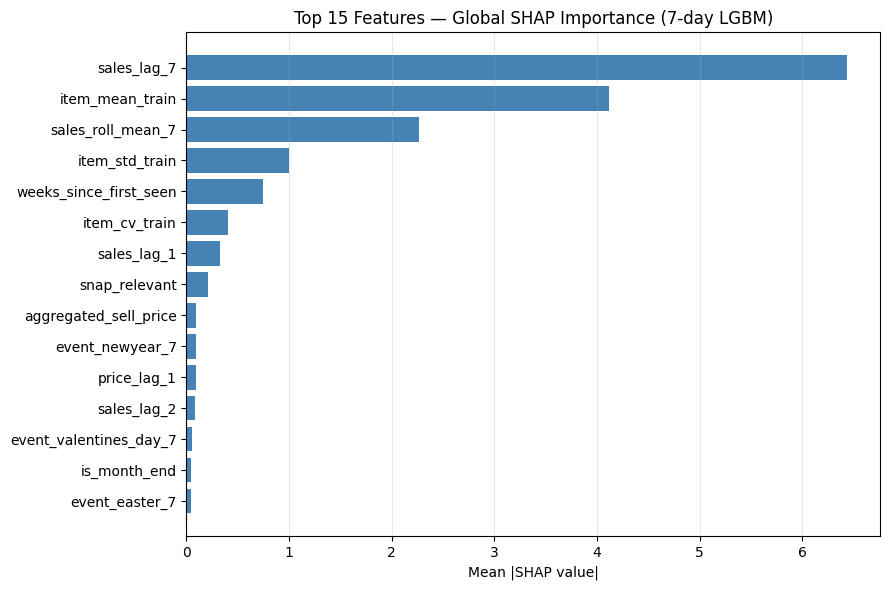

In [5]:
top_n = 15
top_imp = importance_df.head(top_n)
# Strip sklearn prefix for cleaner labels
top_imp = top_imp.copy()
top_imp['feature_clean'] = top_imp['feature'].str.replace('num__', '', regex=False).str.replace('cat__', '', regex=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_imp['feature_clean'][::-1], top_imp['mean_abs_shap'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Top {top_n} Features — Global SHAP Importance (7-day LGBM)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6) SHAP Beeswarm / Summary Dot Plot

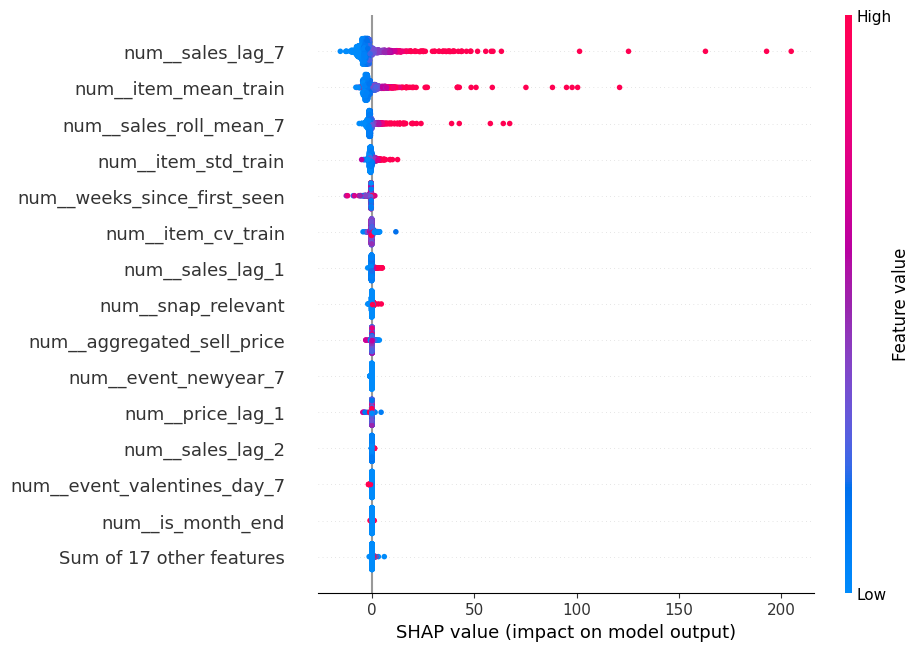

In [6]:
shap.plots.beeswarm(shap_values, max_display=15, show=True)


## 7) NLG Global Explanation (Q2)

In [7]:
explanation_text = generate_global_explanation_text(importance_df)
print(explanation_text)

=== Global Feature Importance Summary ===
The model's demand forecasts are primarily driven by recent sales history (lag and rolling features).

Top 5 features by mean absolute SHAP contribution:
  1. sales_lag_7                          mean |SHAP| = 6.4335
  2. item_mean_train                      mean |SHAP| = 4.1156
  3. sales_roll_mean_7                    mean |SHAP| = 2.2686
  4. item_std_train                       mean |SHAP| = 0.9965
  5. weeks_since_first_seen               mean |SHAP| = 0.7411

These top 5 features collectively account for 90.1% of total SHAP mass across all 31 features.
Lowest-impact features: event_mothers_day_7, event_christmas_7, sales_roll_mean_2, sales_roll_mean_4, sales_roll_std_4.


## 8) Feature Quality Audit (Q8)

In [8]:
audit_df = feature_quality_audit(X_test)
print('=== Feature Quality Audit ===')
print(audit_df.to_string(index=False))

flagged = audit_df[audit_df['flag'] != 'ok']
print(f'\nFlagged features: {len(flagged)}')
if not flagged.empty:
    print(flagged.to_string(index=False))

=== Feature Quality Audit ===
                   feature  missing_pct     std                               flag
              is_month_end          0.0  0.4454                                 ok
               sales_lag_7          0.0 26.1009                                 ok
         sales_roll_mean_7          0.0 26.1009                   high_corr(>0.95)
     aggregated_sell_price          0.0  1.8401                                 ok
            discount_depth          0.0  0.0080                 mostly_zero(98.8%)
         event_christmas_7          0.0  0.0000 zero_variance; mostly_zero(100.0%)
            event_easter_7          0.0  0.2875                 mostly_zero(90.9%)
       event_eid_al_fitr_7          0.0  0.0000 zero_variance; mostly_zero(100.0%)
       event_eid_al_adha_7          0.0  0.0000 zero_variance; mostly_zero(100.0%)
       event_fathers_day_7          0.0  0.0000 zero_variance; mostly_zero(100.0%)
         event_halloween_7          0.0  0.0000 zero_vari

## 8b) Feature Quality Audit — Visualization

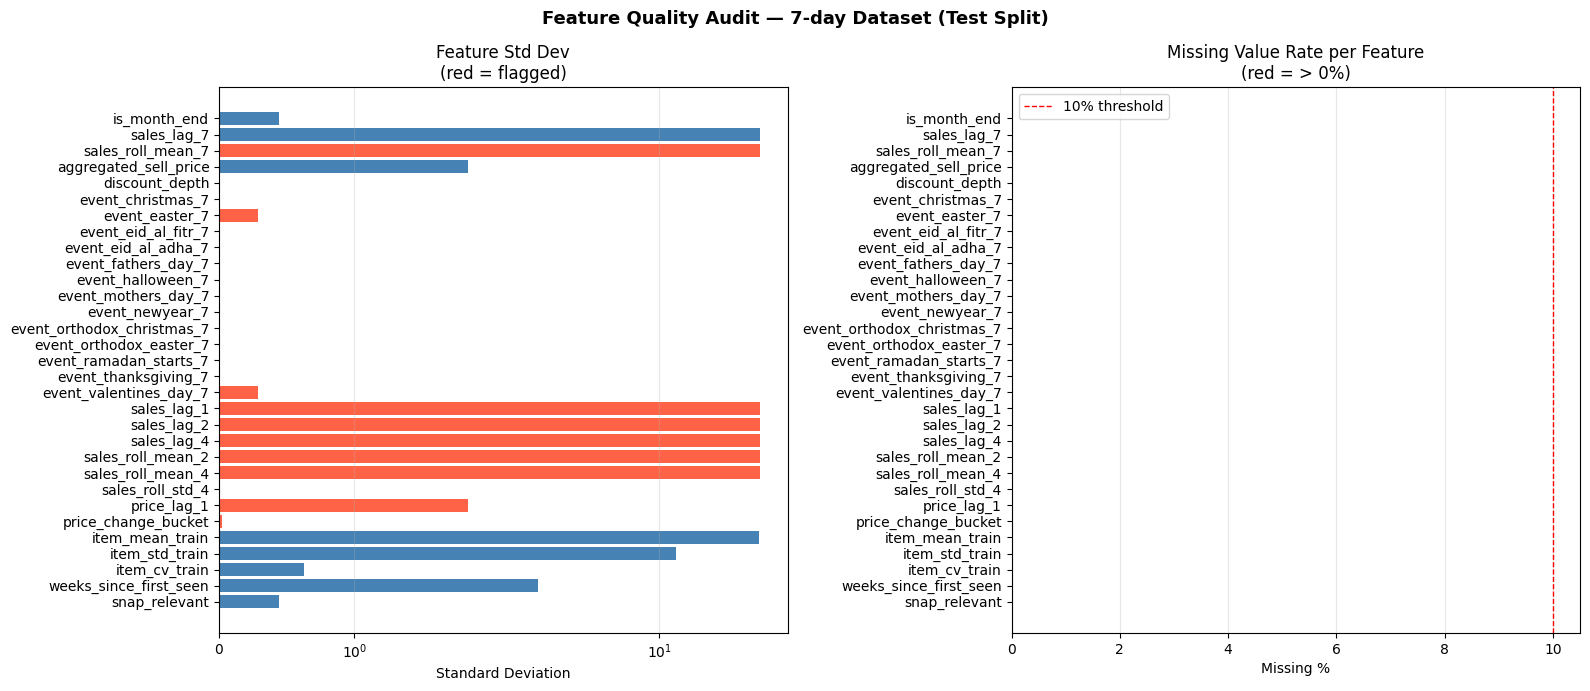

Zero-std features: ['event_christmas_7', 'event_eid_al_fitr_7', 'event_eid_al_adha_7', 'event_fathers_day_7', 'event_halloween_7', 'event_mothers_day_7', 'event_newyear_7', 'event_orthodox_christmas_7', 'event_orthodox_easter_7', 'event_ramadan_starts_7', 'event_thanksgiving_7', 'sales_roll_std_4']
Any missing data:  None


In [9]:
audit_plot = audit_df.copy()
audit_plot['feature_clean'] = audit_plot['feature'].str.replace('num__', '', regex=False).str.replace('cat__', '', regex=False)
audit_plot['flagged'] = audit_plot['flag'] != 'ok'

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_std = ['tomato' if f else 'steelblue' for f in audit_plot['flagged']]
axes[0].barh(audit_plot['feature_clean'][::-1], audit_plot['std'][::-1], color=colors_std[::-1])
axes[0].set_xlabel('Standard Deviation')
axes[0].set_title('Feature Std Dev\n(red = flagged)')
axes[0].set_xscale('symlog')
axes[0].grid(axis='x', alpha=0.3)

colors_miss = ['tomato' if m > 0 else 'steelblue' for m in audit_plot['missing_pct']]
axes[1].barh(audit_plot['feature_clean'][::-1], audit_plot['missing_pct'][::-1], color=colors_miss[::-1])
axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Value Rate per Feature\n(red = > 0%)')
axes[1].axvline(10, color='red', linestyle='--', linewidth=1, label='10% threshold')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Quality Audit — 7-day Dataset (Test Split)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Zero-std features: {audit_plot[audit_plot["std"] == 0.0]["feature_clean"].tolist()}')
print(f'Any missing data:  {audit_plot[audit_plot["missing_pct"] > 0]["feature_clean"].tolist() or "None"}')

## 9) Save Artifacts

In [10]:
imp_path   = REPORTS_DIR / 'global_shap_importance_7d.csv'
audit_path = REPORTS_DIR / 'feature_quality_audit_7d.csv'

importance_df.to_csv(imp_path,   index=False)
audit_df.to_csv(audit_path, index=False)

print('Saved importance:', imp_path)
print('Saved audit:     ', audit_path)

Saved importance: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\global_shap_importance_7d.csv
Saved audit:      C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\feature_quality_audit_7d.csv
